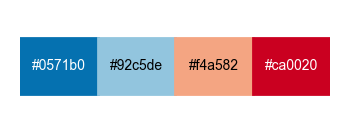

In [20]:
import matplotlib.pyplot as plt

colors = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']
labels = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']

fig, ax = plt.subplots(figsize=(2, 0.6), dpi=200)

for i, (c, lab) in enumerate(zip(colors, labels)):
    # 画色块
    ax.add_patch(plt.Rectangle((i, 0.2), 1, 0.6, color=c))
    
    # 写标签（在色块中间）
    ax.text(i + 0.5, 0.5, lab,
            ha='center', va='center',
            fontsize=5,
            color='white' if i in [0, 3] else 'black')  # 深色用白字更清晰

ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()

In [21]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

In [22]:
import numpy as np

def normalize_abundance_dict(abundance_dict):
    """
    将丰度字典的 value 归一化，使其和为 1。
    
    参数：
        abundance_dict (dict): 例如 {'A': 10, 'B': 30, 'C': 60}
    
    返回：
        dict: 归一化后的字典，例如 {'A': 0.1, 'B': 0.3, 'C': 0.6}
    """
    values = np.array(list(abundance_dict.values()), dtype=float)
    total = values.sum()
    if total > 0:
        normalized_values = values / total
    else:
        normalized_values = np.zeros_like(values)
    
    # 保留 key 的对应关系
    normalized_dict = dict(zip(abundance_dict.keys(), normalized_values))
    return normalized_dict


# input and output

In [23]:
experiment_file = '../../Data/L-DOPA_experimentdata.xlsx'

In [24]:
experiment_data = pd.read_excel(experiment_file,sheet_name = 'Sheet2')
experiment_data

,Unnamed: 0,Unnamed: 1,Unnamed: 2,0520A,0519A,0609A,0511A,0506A,0427A,0705A,...,0612A,0611A,0610C,0602B,0519B,0908B,0805A,0721C,0707B,0610A
0,Taxonomic rank,NCBI,strain,wulu1215_BKDL210003784-1A-9.txt,wulu1215_BKDL210003784-1A-8.txt,wulu1215_BKDL210003784-1A-7.txt,wulu1215_BKDL210003784-1A-5.txt,wulu1215_BKDL210003784-1A-4.txt,wulu1215_BKDL210003784-1A-3.txt,wulu1215_BKDL210003784-1A-20.txt,...,wulu1215_BKDL210003784-1A-18.txt,wulu1215_BKDL210003784-1A-17.txt,wulu1215_BKDL210003784-1A-16.txt,wulu1215_BKDL210003784-1A-13.txt,wulu1215_BKDL210003784-1A-11.txt,wulu0219_3-200908B_FKDL210012333-1a-9_HFJ7LCCX...,wulu0219_1-200805A_FKDL210012331-1a-11_HFJ7LCC...,wulu0219_1-200721C_FKDL210012331-1a-3_HFJ7LCCX...,wulu0219_1-200707B_FKDL210012331-1a-6_HFJ7LCCX...,wulu0219_1-200610A_FKDL210012331-1a-2_HFJ7LCCX...
1,C,1236,Gammaproteobacteria,4.93,2.59,9.96,1.11,2,0.65,3.7,...,1.26,7.44,0.72,0.6,0.72,0.58,0.65,1.58,3.2,1.67
2,C,1760,Actinobacteria,0.58,0.31,4.07,3.67,5.13,0.69,1.42,...,25.34,10.35,20.87,2.55,1.25,5.95,0.19,9.36,1.32,5.64
3,C,3398,Magnoliopsida,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C,28211,Alphaproteobacteria,0.05,0.16,0.04,0.17,0.05,0.14,0.15,...,0.13,0.06,0.1,0.09,0.2,0.12,0.09,0.07,0.1,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17349,U,0,unclassified,13.77,52.42,16.39,40.24,18.87,35.52,40.82,...,22.39,28.68,24.62,20.83,49.89,28.04,27.89,27.39,24.57,35.7
17350,D5,2715732,Microgenomates group incertae sedis,NaN,0,NaN,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17351,R3,36549,plasmids,NaN,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,NaN
17352,C5,71275,rosids,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
def deal_sampleinfo_level(experiment_data, level='F'):
    # 按照 level 筛选
    filtered = experiment_data[experiment_data['Unnamed: 0'] == level]
    # 遍历每一行，取 index 和 'Unnamed: 2' 的内容
    experiment_data_levellist = [
        (idx, str(row['Unnamed: 2']).strip())
        for idx, row in filtered.iterrows()
    ]
    return experiment_data_levellist

experiment_data_levellist = deal_sampleinfo_level(experiment_data, level='F')
experiment_data_levellist

[(178, 'Myxococcaceae'),
 (179, 'Archangiaceae'),
 (180, 'Polyangiaceae'),
 (181, 'Planctomycetaceae'),
 (182, 'Spirochaetaceae'),
 (183, 'Leptospiraceae'),
 (184, 'Methylococcaceae'),
 (185, 'Acetobacteraceae'),
 (186, 'Legionellaceae'),
 (187, 'Moraxellaceae'),
 (188, 'Neisseriaceae'),
 (189, 'Alcaligenaceae'),
 (190, 'Enterobacteriaceae'),
 (191, 'Vibrionaceae'),
 (192, 'Pasteurellaceae'),
 (193, 'Bartonellaceae'),
 (194, 'Rickettsiaceae'),
 (195, 'Chlamydiaceae'),
 (196, 'Bacteroidaceae'),
 (197, 'Cardiobacteriaceae'),
 (198, 'Anaplasmataceae'),
 (199, 'Halanaerobiaceae'),
 (200, 'Chromatiaceae'),
 (201, 'Chloroflexaceae'),
 (202, 'Nostocaceae'),
 (203, 'Scytonemataceae'),
 (204, 'Rivulariaceae'),
 (205, 'Prochloraceae'),
 (206, 'Micrococcaceae'),
 (207, 'Streptococcaceae'),
 (208, 'Corynebacteriaceae'),
 (209, 'Mycobacteriaceae'),
 (210, 'Streptosporangiaceae'),
 (211, 'Thermomonosporaceae'),
 (212, 'Actinomycetaceae'),
 (213, 'Streptomycetaceae'),
 (214, 'Pseudonocardiaceae'),
 (

In [26]:
sampleID_list = list(experiment_data.columns)
sampleID_list = [x for x in sampleID_list if 'Unnamed' not in x]
sampleID_list

['0520A',
 '0519A',
 '0609A',
 '0511A',
 '0506A',
 '0427A',
 '0705A',
 '0421A',
 '0616A',
 '0612A',
 '0611A',
 '0610C',
 '0602B',
 '0519B',
 '0908B',
 '0805A',
 '0721C',
 '0707B',
 '0610A']

In [27]:
def get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist):
    sampleID_abundance = experiment_data[sampleID].to_list()
    abundance_dict = {}
    for index, level in experiment_data_levellist:   # ✅ 不要用 .items()
        if level not in abundance_dict:
            abundance_dict[level] = sampleID_abundance[index]
        else:
            abundance_dict[level] += sampleID_abundance[index]
    abundance_dict = {k:v for k,v in abundance_dict.items() if v>0}
    
    return abundance_dict

sampleID = '0520A'
get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist)

{'Spirochaetaceae': 0.01,
 'Moraxellaceae': 0.03,
 'Enterobacteriaceae': 4.02,
 'Vibrionaceae': 0.01,
 'Pasteurellaceae': 0.64,
 'Bacteroidaceae': 12.14,
 'Micrococcaceae': 0.01,
 'Streptococcaceae': 2.93,
 'Corynebacteriaceae': 0.01,
 'Actinomycetaceae': 0.05,
 'Streptomycetaceae': 0.01,
 'Hominidae': 0.02,
 'Myoviridae': 0.01,
 'Siphoviridae': 0.01,
 'Bifidobacteriaceae': 0.47,
 'Veillonellaceae': 1.18,
 'Clostridiaceae': 0.18,
 'Rhodobacteraceae': 0.01,
 'Xanthomonadaceae': 0.02,
 'Lactobacillaceae': 0.03,
 'Sphingomonadaceae': 0.01,
 'Flavobacteriaceae': 0.02,
 'Campylobacteraceae': 0.02,
 'Comamonadaceae': 0.01,
 'Leuconostocaceae': 0.01,
 'Enterococcaceae': 0.33,
 'Rhizobiaceae': 0.01,
 'Coriobacteriaceae': 0.02,
 'Sphingobacteriaceae': 0.01,
 'Staphylococcaceae': 0.01,
 'Burkholderiaceae': 0.01,
 'Erysipelotrichaceae': 2.97,
 'Pseudomonadaceae': 0.03,
 'Rikenellaceae': 0.04,
 'Prevotellaceae': 0.02,
 'Lachnospiraceae': 19.37,
 'Peptostreptococcaceae': 0.72,
 'Eubacteriaceae': 0.

In [28]:
import math
def calculate_sampleID_score(family_list, abund_dict, enzyme_counts_dict):
    score = 0
    for family in family_list:
        abund = abund_dict.get(family, 0)
        enzyme_count = enzyme_counts_dict.get(family, 0)
        score += (abund ** 1) * (enzyme_count ** 3)
    return score

# levodopa

In [29]:
import json
with open("strain_eccounts_family.json", "r", encoding="utf-8") as f:
    enzyme_eccounts_dict = json.load(f)

# {k:v for k,v in enzyme_eccounts_dict['4.1.1.25'].items() if k in enzyme_counts_dict}

In [30]:
import json
with open('../../Result/ec_strain_enzymecounts_top4_filter_family.json', "r", encoding="utf-8") as f:
    enzyme_eccounts_dict = json.load(f)

print(enzyme_eccounts_dict)

enzyme_counts_dict = enzyme_eccounts_dict['4.1.1.25']
enzyme_counts_dict

{'7.2.2.21': {'Bifidobacteriaceae': 43, 'Bacteroidaceae': 78, 'Porphyromonadaceae': 3, 'Rikenellaceae': 13, 'Enterococcaceae': 1748, 'Streptococcaceae': 1122, 'Turicibacteraceae': 3, 'Clostridiaceae': 57, 'Lachnospiraceae': 65, 'Peptostreptococcaceae': 36, 'Ruminococcaceae': 3, 'Veillonellaceae': 9, 'Erysipelotrichaceae': 36, 'Alcaligenaceae': 12, 'Enterobacteriaceae': 3169}, '7.1.1.2': {'Bifidobacteriaceae': 75, 'Bacteroidaceae': 302, 'Porphyromonadaceae': 6, 'Rikenellaceae': 22, 'Enterococcaceae': 3801, 'Streptococcaceae': 2721, 'Turicibacteraceae': 30, 'Clostridiaceae': 327, 'Lachnospiraceae': 296, 'Peptostreptococcaceae': 110, 'Ruminococcaceae': 9, 'Veillonellaceae': 26, 'Erysipelotrichaceae': 157, 'Alcaligenaceae': 33, 'Enterobacteriaceae': 30305}, '2.7.1.202': {'Bifidobacteriaceae': 81, 'Bacteroidaceae': 234, 'Porphyromonadaceae': 6, 'Rikenellaceae': 26, 'Enterococcaceae': 4301, 'Streptococcaceae': 4788, 'Turicibacteraceae': 35, 'Clostridiaceae': 495, 'Lachnospiraceae': 379, 'Pep

{'Bifidobacteriaceae': 1,
 'Bacteroidaceae': 66,
 'Porphyromonadaceae': 2,
 'Rikenellaceae': 13,
 'Enterococcaceae': 1056,
 'Streptococcaceae': 128,
 'Turicibacteraceae': 0,
 'Clostridiaceae': 112,
 'Lachnospiraceae': 55,
 'Peptostreptococcaceae': 53,
 'Ruminococcaceae': 2,
 'Veillonellaceae': 8,
 'Erysipelotrichaceae': 38,
 'Alcaligenaceae': 8,
 'Enterobacteriaceae': 624}

# 计算每个样本的score

In [32]:
height_data_single = {
    'Enterococcaceae':0,
    'Streptococcaceae': 3.1,
    'Turicibacteraceae': 3.1,
    'Enterobacteriaceae': 3.1,
    'Alcaligenaceae': 3.4,
    'Veillonellaceae': 3.8,
    'Peptostreptococcaceae': 4.1,
    'Porphyromonadaceae': 4.2,
    'Erysipelotrichaceae': 4.5,
    'Clostridiaceae': 4.5,
    'Bifidobacteriaceae': 5.0,
    'Rikenellaceae': 5.3,
    'Bacteroidaceae': 10.0,
    'Ruminococcaceae': 32.0,
    'Lachnospiraceae': 34.0
}

sampleID = '0520A'
abund_dict = get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist)
calculate_sampleID_score(height_data_single.keys(), abund_dict, enzyme_counts_dict)

1378725845.7

In [33]:
score_dict = {}
for sampleID in sampleID_list:
    abund_dict = get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist)
    abund_dict = {k:v/100 for k,v in abund_dict.items()}
    # abund_dict = normalize_abundance_dict(abund_dict)
    score = calculate_sampleID_score(height_data_single.keys(), abund_dict, enzyme_counts_dict)
    score_dict[sampleID] = score 
score_dict

{'0520A': 13787258.456999999,
 '0519A': 2842352.682900001,
 '0609A': 24052901.0378,
 '0511A': 1417866.7951000005,
 '0506A': 4841327.253599999,
 '0427A': 1102067.4776,
 '0705A': 8672413.405900002,
 '0421A': 1933521.4504000002,
 '0616A': 852331.6897,
 '0612A': 2950863.2156,
 '0611A': 17511590.783799995,
 '0610C': 3887363.2334,
 '0602B': 1453315.0626,
 '0519B': 1222703.5906999998,
 '0908B': 992997.86,
 '0805A': 1138867.9122000001,
 '0721C': 2660100.1255000005,
 '0707B': 7274703.999100001,
 '0610A': 2871335.4579999996}

In [ ]:
dopa_dict = {
'0611A':3.692,
'0707B':4.665,
'0610C':5.414,
'0519A':6.608,
'0421A':6.811,
'0612A':10.225,
'0721C':10.488,
'0805A':11.191,
'0705A':11.405,
'0511A':11.585,
'0427C':12,  
'0610A':12.681,  
'0519B':13.088,    
'0908B':15.246,  
'0602B':15.567,  
'0616A':15.901,  
'0427A':16.828,  
'0506A':19.051,  
}
dopa_dict = {k:(30-v)/30 for k,v in dopa_dict.items()}

Pearson r = 0.526, p = 2.997e-02
Pearson r = 0.571, p = 1.663e-02


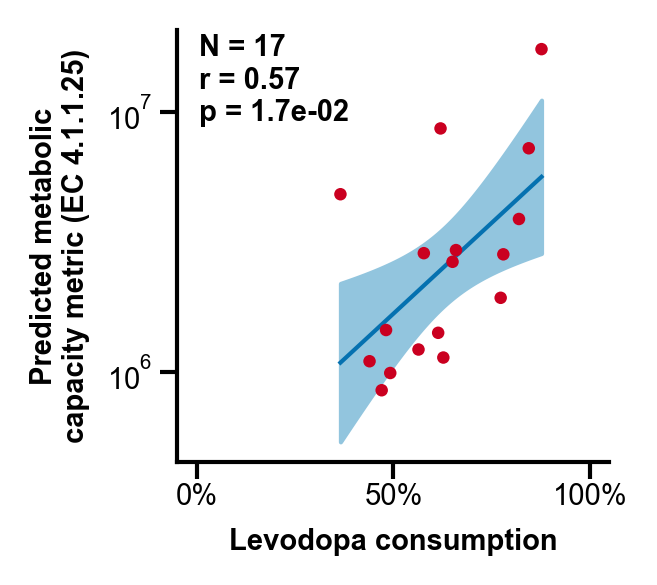

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
import numpy as np

# ===== 数据准备 =====
keys = list(score_dict.keys())

x = np.array([dopa_dict[k] for k in keys])
y = np.array([score_dict[k] for k in keys])

# ===== Pearson（基于 log y，更合理）=====
r, p = pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p = {p:.3e}")
r, p = pearsonr(x, np.log10(y))
print(f"Pearson r = {r:.3f}, p = {p:.3e}")

# ===== 回归（log y）=====
slope, intercept, r_value, p_value, std_err = linregress(x, np.log10(y))

x_fit = np.linspace(min(x), max(x), 100)
y_fit_log = intercept + slope * x_fit
y_fit = 10 ** y_fit_log

# ===== 纺锤型 CI（regression CI）=====
n = len(x)
x_bar = np.mean(x)
Sxx = np.sum((x - x_bar)**2)

# 残差标准误
s_err = np.sqrt(np.sum((np.log10(y) - (intercept + slope * x))**2) / (n - 2))

# CI宽度（随x变化 → 纺锤型）
ci = 1.96 * s_err * np.sqrt(
    1/n + (x_fit - x_bar)**2 / Sxx
)

y_upper = 10 ** (y_fit_log + ci)
y_lower = 10 ** (y_fit_log - ci)

# ===== 画布 =====
plt.figure(figsize=(1.8, 1.8), dpi=300)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)
ax.set_position([0.2, 0.2, 0.8, 0.8]) 

# ===== 散点 =====
plt.scatter(x, y, s=9, alpha=1, color='#ca0020', edgecolors='none', zorder=3)

# ===== 回归线 + 纺锤CI =====
plt.plot(x_fit, y_fit, color='#0571b0', linewidth=1, zorder=2)
plt.fill_between(x_fit, y_lower, y_upper,
                 color='#92c5de', alpha=1, zorder=1)

# ===== label（可选）=====
# for i, k in enumerate(keys):
#     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

# ===== log y轴 =====
from matplotlib.ticker import LogLocator

plt.yscale("log")

ax = plt.gca()
ax.yaxis.set_major_locator(LogLocator(base=10.0))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))

# ===== 统计标注 =====
plt.text(0.05, 0.99,
         f"N = {len(x)}\nr = {r:.2f}\np = {p:.1e}",
         transform=plt.gca().transAxes,
         fontsize=7, fontweight='bold', va="top", ha='left')

# ===== 坐标轴 =====
plt.xlabel("Levodopa consumption", fontsize=7, fontweight='bold')
plt.ylabel("Predicted metabolic\ncapacity metric (EC 4.1.1.25)", fontsize=7, fontweight='bold')

plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

plt.xlim(-0.05, 1.05)
import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# plt.ylim(5e5, 2e7)

plt.savefig('../../Figure/Figure-2g.pdf', dpi=400, bbox_inches='tight')
plt.show()